# 1D Burgers Data-Driven Parameter Discovery PINN - Loss Tests

*Last edited: 2024-05-06*  

Based on: <https://github.com/maziarraissi/PINNs/tree/master/appendix/continuous_time_identification%20(Burgers)>.


The purpose of this Notebook is to carry out some tests with the PINN loss function.

Terms:

* **Discorery** is when the network is able to identify the underlying partial differential equation.

* **Continous time** models take into account the exact time interval between measurements.

In the train phase the neural network estimates a solution $u(t,x)$.
The function employed by the PINN, $f(t,x)$ (Equation 2), is derived from the known Burgers' equation, and allows calculating the loss function.
The parameters of the differential operator that we want to obtain are transformed into PINN parameters.
In the following equations, the differential operator parameter $\lambda_1$ (or $u$) is the speed of fluid at the indicated spatial and temporal coordinates, the differential operator parameter $\lambda_2$ (or $\nu$) is the kinematic viscosity of fluid, and the subscripts denote partial differentiation in time and space, respectively, as
$u_t$ (which denotes $\frac{du}{dt}$), 
$u_x$ (which denotes $\frac{du}{dx}$), and 
$u_{xx}$ (which denotes $\frac{d^2u}{dx^2}$).

$$
u_t + \lambda_1 u_x - \lambda_2 u_{xx} = 0, \quad x \in [-1,1], \ t \in [0, 1]  \tag{1}
$$

The Burgers' equation is employed to evaluate the error $f$ of the solution $u(t,x)$ estimated by the PINN, as shown in Equation 2.

$$
f := u_t + \lambda_1 u_x - \lambda_2 u_{xx} \tag{2}
$$

## Libraries & Setup

In [1]:
%env TF_CPP_MIN_LOG_LEVEL=3
import tensorflow as tf

tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)
# Prevent tensorflow from allocating all GPU memory
configuration = tf.compat.v1.ConfigProto()
configuration.gpu_options.allow_growth = True
session = tf.compat.v1.Session(config=configuration)
tf.compat.v1.set_random_seed(1234)  # Reproducibility
print(tf.__version__)

from scipy.interpolate import griddata
import scipy.io

from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt

my_rc_param = {'text.usetex': False}
plt.rcParams.update(my_rc_param)

import time
import os
import numpy as np

np.random.seed(1234)  # Reproducibility

env: TF_CPP_MIN_LOG_LEVEL=3
1.15.0


## Plotting module

In [2]:
def figsize(scale, nplots=1):
    fig_width_pt = 390.0  # Get this from LaTeX using \the\textwidth
    inches_per_pt = 1.0 / 72.27  # Convert pt to inch

    # Aesthetic ratio (you could change this)
    golden_mean = (np.sqrt(5.0) - 1.0) / 2.0

    fig_width = fig_width_pt * inches_per_pt * scale  # width in inches
    fig_height = nplots * fig_width * golden_mean  # height in inches
    fig_size = [fig_width, fig_height]
    return fig_size


def newfig(width, nplots=1):
    # fig = plt.figure(figsize=figsize(width, nplots)) #latex
    fig = plt.figure()
    ax = fig.add_subplot(111)
    return fig, ax

## PINN

L-BFGS-B parameters (<https://docs.scipy.org/doc/scipy/reference/optimize.minimize-lbfgsb.html>):
- *maxiter* - Maximum number of iterations.
- *maxfun* - maximum number of function evaluations. Note that this function may violate the limit because of evaluating gradients by numerical differentiation.
- *maxcor* - the maximum number of variable metric corrections used to define the limited memory matrix. (The limited memory BFGS method does not store the full hessian but uses this many terms in an approximation to it.)
- *ftol* - the iteration stops when $(f^k - f^{k+1})/max{|f^k|,|f^{k+1}|,1}$ <= ftol.
- *maxls* - maximum number of line search steps (per iteration). Default is 20.

NOTES
* `placeholder` is a variable in Tensorflow to which data will be assigned sometime later on. It enables us to create processes or operations without the requirement for data. Data is fed into the placeholder as the session starts, and the session is run. We can feed in data into tensorflow graphs using placeholders.

# Loss 1 - ORIGINAL FUNCTION

In [53]:
class PhysicsInformedNN1:

    def __init__(self, X, u, layers, lb, ub):
        self.lb = lb
        self.ub = ub
        self.x = X[:, 0:1]
        self.t = X[:, 1:2]
        self.u = u
        self.layers = layers
        # Initialize NNs
        self.weights, self.biases = self.initialize_NN(layers)
        # tf placeholders and graph
        self.sess = tf.Session(config=tf.ConfigProto(allow_soft_placement=True,
                                                     log_device_placement=True))
        # Initialize parameters
        self.lambda_1 = tf.Variable([0.0], dtype=tf.float32)
        self.lambda_2 = tf.Variable([-6.0], dtype=tf.float32)
        self.x_tf = tf.placeholder(tf.float32, shape=[None, self.x.shape[1]])
        self.t_tf = tf.placeholder(tf.float32, shape=[None, self.t.shape[1]])
        self.u_tf = tf.placeholder(tf.float32, shape=[None, self.u.shape[1]])
        self.u_pred = self.net_u(self.x_tf, self.t_tf)
        self.f_pred = self.net_f(self.x_tf, self.t_tf)

### LOSS FUNCTION ##########################################################

        # ORIGINAL FUNCTION
        self.loss = (tf.reduce_mean(tf.square(self.u_tf - self.u_pred)) +  # MSE_u
                     tf.reduce_mean(tf.square(self.f_pred)))               # MSE_f
        
############################################################################

        # L-BFGS-B optimizer
        # https://docs.scipy.org/doc/scipy/reference/optimize.minimize-lbfgsb.html
        self.optimizer = tf.contrib.opt.ScipyOptimizerInterface(
            self.loss,
            method='L-BFGS-B',
            options={
                'maxiter': 50000,
                'maxfun': 50000,
                'maxcor': 50,
                'maxls': 50,
                # The smallest representable number such that 1.0 + eps != 1.0
                'ftol': 1.0 * np.finfo(float).eps
            })

        # Adam optimizer
        #self.optimizer_Adam = tf.train.AdamOptimizer()
        #self.train_op_Adam = self.optimizer_Adam.minimize(self.loss)

        # TF startup
        init = tf.global_variables_initializer()
        self.sess.run(init)

    def xavier_init(self, size):
        in_dim = size[0]
        out_dim = size[1]
        xavier_stddev = np.sqrt(2 / (in_dim + out_dim))
        return tf.Variable(tf.truncated_normal([in_dim, out_dim],
                                               stddev=xavier_stddev),
                           dtype=tf.float32)

    # structure definition
    def initialize_NN(self, layers):
        weights = []
        biases = []
        num_layers = len(layers)
        for l in range(0, num_layers - 1):
            W = self.xavier_init(size=[layers[l], layers[l + 1]])
            b = tf.Variable(tf.zeros([1, layers[l + 1]], dtype=tf.float32),
                            dtype=tf.float32)
            weights.append(W)
            biases.append(b)
        return weights, biases

    def neural_net(self, X, weights, biases):
        num_layers = len(weights) + 1
        H = 2.0 * (X - self.lb) / (self.ub - self.lb) - 1.0
        for l in range(0, num_layers - 2):
            W = weights[l]
            b = biases[l]
            H = tf.tanh(tf.add(tf.matmul(H, W), b))
        W = weights[-1]
        b = biases[-1]
        Y = tf.add(tf.matmul(H, W), b)
        return Y

    def net_u(self, x, t):
        u = self.neural_net(tf.concat([x, t], 1), self.weights, self.biases)
        return u

    def net_f(self, x, t):
        lambda_1 = self.lambda_1
        lambda_2 = tf.exp(self.lambda_2)
        u = self.net_u(x, t)
        u_t = tf.gradients(u, t)[0]
        u_x = tf.gradients(u, x)[0]
        u_xx = tf.gradients(u_x, x)[0]
        f = u_t + lambda_1 * u * u_x - lambda_2 * u_xx
        return f

    # train definition
    def callback(self, loss, lambda_1, lambda_2):
        print('Loss: %e, Lambda_1: %.5f, Lambda_2: %.5f'
              % (loss, lambda_1, np.exp(lambda_2)))

    def train(self, nIter):
        tf_dict = {self.x_tf: self.x, self.t_tf: self.t, self.u_tf: self.u}

        # print("=== start Adam optimizer ===")
        # for it in range(nIter):
        #     self.sess.run(self.train_op_Adam, tf_dict)
        #     if it % 100 == 0:
        #         loss_value = self.sess.run(self.loss, tf_dict)
        #         lambda_1_value = self.sess.run(self.lambda_1)
        #         lambda_2_value = np.exp(self.sess.run(self.lambda_2))
        #         print('Loss: %.3e, Lambda_1: %.3f, Lambda_2: %.6f'
        #             % (loss_value, lambda_1_value, lambda_2_value))

        print("L-BFGS-B optimizer run.")
        self.optimizer.minimize(
            self.sess,
            feed_dict=tf_dict,
            fetches=[self.loss, self.lambda_1, self.lambda_2],
            loss_callback=self.callback
        )

    # prediction definition
    def predict(self, X_star):
        tf_dict = {self.x_tf: X_star[:, 0:1], self.t_tf: X_star[:, 1:2]}
        u_star = self.sess.run(self.u_pred, tf_dict)
        f_star = self.sess.run(self.f_pred, tf_dict)
        return u_star, f_star

## Loss 2 - without MSE_f

In [76]:
class PhysicsInformedNN2:

    def __init__(self, X, u, layers, lb, ub):
        self.lb = lb
        self.ub = ub
        self.x = X[:, 0:1]
        self.t = X[:, 1:2]
        self.u = u
        self.layers = layers
        # Initialize NNs
        self.weights, self.biases = self.initialize_NN(layers)
        # tf placeholders and graph
        self.sess = tf.Session(config=tf.ConfigProto(allow_soft_placement=True,
                                                     log_device_placement=True))
        # Initialize parameters
        self.lambda_1 = tf.Variable([0.0], dtype=tf.float32)
        self.lambda_2 = tf.Variable([-6.0], dtype=tf.float32)
        self.x_tf = tf.placeholder(tf.float32, shape=[None, self.x.shape[1]])
        self.t_tf = tf.placeholder(tf.float32, shape=[None, self.t.shape[1]])
        self.u_tf = tf.placeholder(tf.float32, shape=[None, self.u.shape[1]])
        self.u_pred = self.net_u(self.x_tf, self.t_tf)
        self.f_pred = self.net_f(self.x_tf, self.t_tf)

### LOSS FUNCTION ##########################################################

        # ORIGINAL FUNCTION
        # self.loss = (tf.reduce_mean(tf.square(self.u_tf - self.u_pred)) +  # MSE_u
        #              tf.reduce_mean(tf.square(self.f_pred)))               # MSE_f

        # without MSE_f
        self.loss = (tf.reduce_mean(tf.square(self.u_tf - self.u_pred)))     # MSE_u
        
############################################################################

        # L-BFGS-B optimizer
        # https://docs.scipy.org/doc/scipy/reference/optimize.minimize-lbfgsb.html
        self.optimizer = tf.contrib.opt.ScipyOptimizerInterface(
            self.loss,
            method='L-BFGS-B',
            options={
                'maxiter': 50000,
                'maxfun': 50000,
                'maxcor': 50,
                'maxls': 50,
                # The smallest representable number such that 1.0 + eps != 1.0
                'ftol': 1.0 * np.finfo(float).eps
            })

        # Adam optimizer
        #self.optimizer_Adam = tf.train.AdamOptimizer()
        #self.train_op_Adam = self.optimizer_Adam.minimize(self.loss)

        # TF startup
        init = tf.global_variables_initializer()
        self.sess.run(init)

    def xavier_init(self, size):
        in_dim = size[0]
        out_dim = size[1]
        xavier_stddev = np.sqrt(2 / (in_dim + out_dim))
        return tf.Variable(tf.truncated_normal([in_dim, out_dim],
                                               stddev=xavier_stddev),
                           dtype=tf.float32)

    # structure definition
    def initialize_NN(self, layers):
        weights = []
        biases = []
        num_layers = len(layers)
        for l in range(0, num_layers - 1):
            W = self.xavier_init(size=[layers[l], layers[l + 1]])
            b = tf.Variable(tf.zeros([1, layers[l + 1]], dtype=tf.float32),
                            dtype=tf.float32)
            weights.append(W)
            biases.append(b)
        return weights, biases

    def neural_net(self, X, weights, biases):
        num_layers = len(weights) + 1
        H = 2.0 * (X - self.lb) / (self.ub - self.lb) - 1.0
        for l in range(0, num_layers - 2):
            W = weights[l]
            b = biases[l]
            H = tf.tanh(tf.add(tf.matmul(H, W), b))
        W = weights[-1]
        b = biases[-1]
        Y = tf.add(tf.matmul(H, W), b)
        return Y

    def net_u(self, x, t):
        u = self.neural_net(tf.concat([x, t], 1), self.weights, self.biases)
        return u

    def net_f(self, x, t):
        lambda_1 = self.lambda_1
        lambda_2 = tf.exp(self.lambda_2)
        u = self.net_u(x, t)
        u_t = tf.gradients(u, t)[0]
        u_x = tf.gradients(u, x)[0]
        u_xx = tf.gradients(u_x, x)[0]
        f = u_t + lambda_1 * u * u_x - lambda_2 * u_xx
        return f

    # train definition
    def callback(self, loss, lambda_1, lambda_2):
        print('Loss: %e, Lambda_1: %.5f, Lambda_2: %.5f'
              % (loss, lambda_1, np.exp(lambda_2)))

    def train(self, nIter):
        tf_dict = {self.x_tf: self.x, self.t_tf: self.t, self.u_tf: self.u}

        # print("=== start Adam optimizer ===")
        # for it in range(nIter):
        #     self.sess.run(self.train_op_Adam, tf_dict)
        #     if it % 100 == 0:
        #         loss_value = self.sess.run(self.loss, tf_dict)
        #         lambda_1_value = self.sess.run(self.lambda_1)
        #         lambda_2_value = np.exp(self.sess.run(self.lambda_2))
        #         print('Loss: %.3e, Lambda_1: %.3f, Lambda_2: %.6f'
        #             % (loss_value, lambda_1_value, lambda_2_value))

        print("L-BFGS-B optimizer run.")
        self.optimizer.minimize(
            self.sess,
            feed_dict=tf_dict,
            fetches=[self.loss, self.lambda_1, self.lambda_2],
            loss_callback=self.callback
        )

    # prediction definition
    def predict(self, X_star):
        tf_dict = {self.x_tf: X_star[:, 0:1], self.t_tf: X_star[:, 1:2]}
        u_star = self.sess.run(self.u_pred, tf_dict)
        f_star = self.sess.run(self.f_pred, tf_dict)
        return u_star, f_star

## Loss 3 - without MSE_u

In [77]:
class PhysicsInformedNN3:

    def __init__(self, X, u, layers, lb, ub):
        self.lb = lb
        self.ub = ub
        self.x = X[:, 0:1]
        self.t = X[:, 1:2]
        self.u = u
        self.layers = layers
        # Initialize NNs
        self.weights, self.biases = self.initialize_NN(layers)
        # tf placeholders and graph
        self.sess = tf.Session(config=tf.ConfigProto(allow_soft_placement=True,
                                                     log_device_placement=True))
        # Initialize parameters
        self.lambda_1 = tf.Variable([0.0], dtype=tf.float32)
        self.lambda_2 = tf.Variable([-6.0], dtype=tf.float32)
        self.x_tf = tf.placeholder(tf.float32, shape=[None, self.x.shape[1]])
        self.t_tf = tf.placeholder(tf.float32, shape=[None, self.t.shape[1]])
        self.u_tf = tf.placeholder(tf.float32, shape=[None, self.u.shape[1]])
        self.u_pred = self.net_u(self.x_tf, self.t_tf)
        self.f_pred = self.net_f(self.x_tf, self.t_tf)

### LOSS FUNCTION ##########################################################

        # ORIGINAL FUNCTION
        # self.loss = (tf.reduce_mean(tf.square(self.u_tf - self.u_pred)) +  # MSE_u
        #              tf.reduce_mean(tf.square(self.f_pred)))               # MSE_f

        # without MSE_u
        self.loss = (tf.reduce_mean(tf.square(self.f_pred)))                 # MSE_f
        
############################################################################

        # L-BFGS-B optimizer
        # https://docs.scipy.org/doc/scipy/reference/optimize.minimize-lbfgsb.html
        self.optimizer = tf.contrib.opt.ScipyOptimizerInterface(
            self.loss,
            method='L-BFGS-B',
            options={
                'maxiter': 50000,
                'maxfun': 50000,
                'maxcor': 50,
                'maxls': 50,
                # The smallest representable number such that 1.0 + eps != 1.0
                'ftol': 1.0 * np.finfo(float).eps
            })

        # Adam optimizer
        #self.optimizer_Adam = tf.train.AdamOptimizer()
        #self.train_op_Adam = self.optimizer_Adam.minimize(self.loss)

        # TF startup
        init = tf.global_variables_initializer()
        self.sess.run(init)

    def xavier_init(self, size):
        in_dim = size[0]
        out_dim = size[1]
        xavier_stddev = np.sqrt(2 / (in_dim + out_dim))
        return tf.Variable(tf.truncated_normal([in_dim, out_dim],
                                               stddev=xavier_stddev),
                           dtype=tf.float32)

    # structure definition
    def initialize_NN(self, layers):
        weights = []
        biases = []
        num_layers = len(layers)
        for l in range(0, num_layers - 1):
            W = self.xavier_init(size=[layers[l], layers[l + 1]])
            b = tf.Variable(tf.zeros([1, layers[l + 1]], dtype=tf.float32),
                            dtype=tf.float32)
            weights.append(W)
            biases.append(b)
        return weights, biases

    def neural_net(self, X, weights, biases):
        num_layers = len(weights) + 1
        H = 2.0 * (X - self.lb) / (self.ub - self.lb) - 1.0
        for l in range(0, num_layers - 2):
            W = weights[l]
            b = biases[l]
            H = tf.tanh(tf.add(tf.matmul(H, W), b))
        W = weights[-1]
        b = biases[-1]
        Y = tf.add(tf.matmul(H, W), b)
        return Y

    def net_u(self, x, t):
        u = self.neural_net(tf.concat([x, t], 1), self.weights, self.biases)
        return u

    def net_f(self, x, t):
        lambda_1 = self.lambda_1
        lambda_2 = tf.exp(self.lambda_2)
        u = self.net_u(x, t)
        u_t = tf.gradients(u, t)[0]
        u_x = tf.gradients(u, x)[0]
        u_xx = tf.gradients(u_x, x)[0]
        f = u_t + lambda_1 * u * u_x - lambda_2 * u_xx
        return f

    # train definition
    def callback(self, loss, lambda_1, lambda_2):
        print('Loss: %e, Lambda_1: %.5f, Lambda_2: %.5f'
              % (loss, lambda_1, np.exp(lambda_2)))

    def train(self, nIter):
        tf_dict = {self.x_tf: self.x, self.t_tf: self.t, self.u_tf: self.u}

        # print("=== start Adam optimizer ===")
        # for it in range(nIter):
        #     self.sess.run(self.train_op_Adam, tf_dict)
        #     if it % 100 == 0:
        #         loss_value = self.sess.run(self.loss, tf_dict)
        #         lambda_1_value = self.sess.run(self.lambda_1)
        #         lambda_2_value = np.exp(self.sess.run(self.lambda_2))
        #         print('Loss: %.3e, Lambda_1: %.3f, Lambda_2: %.6f'
        #             % (loss_value, lambda_1_value, lambda_2_value))

        print("L-BFGS-B optimizer run.")
        self.optimizer.minimize(
            self.sess,
            feed_dict=tf_dict,
            fetches=[self.loss, self.lambda_1, self.lambda_2],
            loss_callback=self.callback
        )

    # prediction definition
    def predict(self, X_star):
        tf_dict = {self.x_tf: X_star[:, 0:1], self.t_tf: X_star[:, 1:2]}
        u_star = self.sess.run(self.u_pred, tf_dict)
        f_star = self.sess.run(self.f_pred, tf_dict)
        return u_star, f_star

<hr style="height:50px;border-width:0;background-color:green">

## Loss 1 - ORIGINAL

viscosity = 0.01/np.pi

dataset = 256x128

In [54]:
nu = 0.01/np.pi  # viscosity
N_u = 2000  # nro of CPs
layers = [2, 20, 20, 20, 1]  # achitecture
data = np.load('../data/burgers256x128.npz')

## Main

In [55]:
t = data['t'].flatten()[:, None]
x = data['x'].flatten()[:, None]
Exact = np.real(data['usol']).T
X, T = np.meshgrid(x, t)
X_star = np.hstack((X.flatten()[:, None], T.flatten()[:, None]))
u_star = Exact.flatten()[:, None]

# Doman bounds
lb = X_star.min(0)
ub = X_star.max(0)

idx = np.random.choice(X_star.shape[0], N_u, replace=False)
X_u_train = X_star[idx, :]
u_train = u_star[idx, :]

In [56]:
x.size, t.size, Exact.size

(256, 128, 32768)

## Model

In [57]:
%%time
model = PhysicsInformedNN1(X_u_train, u_train, layers, lb, ub)

Device mapping:
/job:localhost/replica:0/task:0/device:XLA_CPU:0 -> device: XLA_CPU device
/job:localhost/replica:0/task:0/device:XLA_GPU:0 -> device: XLA_GPU device
/job:localhost/replica:0/task:0/device:GPU:0 -> device: 0, name: NVIDIA GeForce GTX 1050, pci bus id: 0000:01:00.0, compute capability: 6.1

e_252/shape: (Const): /job:localhost/replica:0/task:0/device:GPU:0
Reshape_253/shape: (Const): /job:localhost/replica:0/task:0/device:GPU:0
Reshape_254/shape: (Const): /job:localhost/replica:0/task:0/device:GPU:0
Reshape_255/shape: (Const): /job:localhost/replica:0/task:0/device:GPU:0
Reshape_256/shape: (Const): /job:localhost/replica:0/task:0/device:GPU:0
Reshape_257/shape: (Const): /job:localhost/replica:0/task:0/device:GPU:0
Reshape_258/shape: (Const): /job:localhost/replica:0/task:0/device:GPU:0
Reshape_259/shape: (Const): /job:localhost/replica:0/task:0/device:GPU:0
concat_14/axis: (Const): /job:localhost/replica:0/task:0/device:GPU:0
Reshape_260/shape: (Const): /job:localhost/re

## Train

Computing-intensive part

In [58]:
%%time
model.train(0)

L-BFGS-B optimizer run.
Loss: 5.492159e-01, Lambda_1: 0.00000, Lambda_2: 0.00248
Loss: 6.122404e+00, Lambda_1: -0.00013, Lambda_2: 0.00248
Loss: 4.214789e-01, Lambda_1: -0.00001, Lambda_2: 0.00248
Loss: 4.049690e-01, Lambda_1: -0.00001, Lambda_2: 0.00248
Loss: 3.513761e-01, Lambda_1: -0.00001, Lambda_2: 0.00248
Loss: 2.599253e-01, Lambda_1: -0.00002, Lambda_2: 0.00248
Loss: 2.543665e-01, Lambda_1: -0.00042, Lambda_2: 0.00248
Loss: 2.504509e-01, Lambda_1: -0.00060, Lambda_2: 0.00248
Loss: 2.495595e-01, Lambda_1: -0.00070, Lambda_2: 0.00248
Loss: 2.475367e-01, Lambda_1: -0.00116, Lambda_2: 0.00248
Loss: 2.420584e-01, Lambda_1: -0.00285, Lambda_2: 0.00248
Loss: 2.472661e-01, Lambda_1: -0.00873, Lambda_2: 0.00248
Loss: 2.349014e-01, Lambda_1: -0.00563, Lambda_2: 0.00248
Loss: 2.422898e-01, Lambda_1: -0.01014, Lambda_2: 0.00248
Loss: 2.315823e-01, Lambda_1: -0.00735, Lambda_2: 0.00248
Loss: 2.294811e-01, Lambda_1: -0.00833, Lambda_2: 0.00248
Loss: 2.227846e-01, Lambda_1: -0.00948, Lambda_2:

## Predict

In [61]:
%%time
u_pred, f_pred = model.predict(X_star)
U_pred = griddata(X_star, u_pred.flatten(), (X, T), method='cubic')

CPU times: user 856 ms, sys: 152 ms, total: 1.01 s
Wall time: 875 ms


### Show the identified PDE

In [63]:
lambda_1_value = model.sess.run(model.lambda_1)
lambda_2_value = model.sess.run(model.lambda_2)
lambda_2_value = np.exp(lambda_2_value)

In [64]:
print(r'Correct PDE   :  u_t + 1.0 u u_x - 0.0031831 u_{xx} = 0')
print(r'Identified PDE: ',
      r'u_t + %.5f u u_x - %.7f u_{xx} = 0' % (lambda_1_value, lambda_2_value))

Correct PDE   :  u_t + 1.0 u u_x - 0.0031831 u_{xx} = 0
Identified PDE:  u_t + 1.00034 u u_x - 0.0031743 u_{xx} = 0


## Error

- Uses the L2 norm (Euclidean distance)
- errou_u = distance error relative to distance

In [14]:
error_u = np.linalg.norm(u_star - u_pred, 2) / np.linalg.norm(u_star, 2)
error_lambda_1 = np.abs(lambda_1_value - 1.0) * 100
error_lambda_2 = np.abs(lambda_2_value - nu) / nu * 100
print('Error u: %e' % (error_u))
print('Error l1: %.5f%%' % (error_lambda_1))
print('Error l2: %.5f%%' % (error_lambda_2))

Error u: 3.004526e-03
Error l1: 0.04878%
Error l2: 1.12258%


## Plotting

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


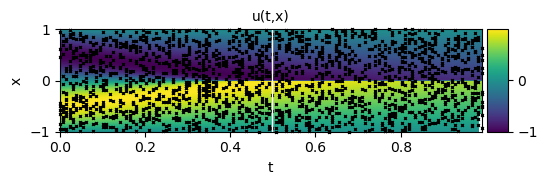

In [15]:
fig, ax = newfig(1.2, 1.2)
ax.axis('off')

# u(t,x)

gs0 = gridspec.GridSpec(1, 2)
gs0.update(top=1 - 0.06,
           bottom=1 - 1.0 / 3.0 + 0.06,
           left=0.15,
           right=0.85,
           wspace=0)
ax = plt.subplot(gs0[:, :])

h = ax.imshow(U_pred.T,
              interpolation='nearest',
              cmap='viridis',
              extent=[t.min(), t.max(), x.min(),
                      x.max()],
              origin='lower',
              aspect='auto')
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(h, cax=cax)

ax.plot(X_u_train[:, 1],
        X_u_train[:, 0],
        'kx',
        #label='Data (%d points)' % (u_train.shape[0]),
        markersize=2,
        clip_on=False)

t50 = t.size//2
line = np.linspace(x.min(), x.max(), 2)[:, None]
#ax.plot(t[25] * np.ones((2, 1)), line, 'w-', linewidth=1)
ax.plot(t[t50] * np.ones((2, 1)), line, 'w-', linewidth=1)
#ax.plot(t[75] * np.ones((2, 1)), line, 'w-', linewidth=1)

ax.set_xlabel('t')
ax.set_ylabel('x')
ax.legend(loc='upper center',
          bbox_to_anchor=(1.0, -0.125),
          ncol=5,
          frameon=False)
ax.set_title('u(t,x)', fontsize=10)

plt.show()

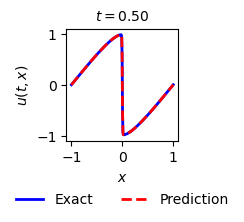

In [16]:
# u(t,x) slices

gs1 = gridspec.GridSpec(1, 1)
gs1.update(top=1 - 1.0 / 3.0 - 0.1,
           bottom=1.0 - 2.0 / 3.0,
           left=0.1,
           right=0.9,
           wspace=0.5)

ax = plt.subplot(gs1[0, 0])
ax.plot(x, Exact[t50, :], 'b-', linewidth=2, label='Exact')
ax.plot(x, U_pred[t50, :], 'r--', linewidth=2, label='Prediction')
ax.set_xlabel('$x$')
ax.set_ylabel('$u(t,x)$')
ax.axis('square')
ax.set_xlim([-1.1, 1.1])
ax.set_ylim([-1.1, 1.1])
ax.set_title('$t = 0.50$', fontsize=10)
ax.legend(loc='upper center',
          bbox_to_anchor=(0.5, -0.35),
          ncol=5,
          frameon=False)

plt.show()

<hr style="height:50px;border-width:0;background-color:green">

## Loss 2 without MSE_f

viscosity = 0.01/np.pi

dataset = 256x128

In [78]:
nu = 0.01/np.pi  # viscosity
N_u = 2000  # nro of CPs
layers = [2, 20, 20, 20, 1]  # achitecture
data = np.load('../data/burgers256x128.npz')

## Main

In [79]:
t = data['t'].flatten()[:, None]
x = data['x'].flatten()[:, None]
Exact = np.real(data['usol']).T
X, T = np.meshgrid(x, t)
X_star = np.hstack((X.flatten()[:, None], T.flatten()[:, None]))
u_star = Exact.flatten()[:, None]

# Doman bounds
lb = X_star.min(0)
ub = X_star.max(0)

idx = np.random.choice(X_star.shape[0], N_u, replace=False)
X_u_train = X_star[idx, :]
u_train = u_star[idx, :]

In [80]:
x.size, t.size, Exact.size

(256, 128, 32768)

## Model

In [81]:
%%time
model = PhysicsInformedNN2(X_u_train, u_train, layers, lb, ub)

Device mapping:
/job:localhost/replica:0/task:0/device:XLA_CPU:0 -> device: XLA_CPU device
/job:localhost/replica:0/task:0/device:XLA_GPU:0 -> device: XLA_GPU device
/job:localhost/replica:0/task:0/device:GPU:0 -> device: 0, name: NVIDIA GeForce GTX 1050, pci bus id: 0000:01:00.0, compute capability: 6.1

ca:0/task:0/device:GPU:0
Reshape_581/shape: (Const): /job:localhost/replica:0/task:0/device:GPU:0
Reshape_582/shape: (Const): /job:localhost/replica:0/task:0/device:GPU:0
Reshape_583/shape: (Const): /job:localhost/replica:0/task:0/device:GPU:0
Reshape_584/shape: (Const): /job:localhost/replica:0/task:0/device:GPU:0
Reshape_585/shape: (Const): /job:localhost/replica:0/task:0/device:GPU:0
Reshape_586/shape: (Const): /job:localhost/replica:0/task:0/device:GPU:0
Reshape_587/shape: (Const): /job:localhost/replica:0/task:0/device:GPU:0
Reshape_588/shape: (Const): /job:localhost/replica:0/task:0/device:GPU:0
Reshape_589/shape: (Const): /job:localhost/replica:0/task:0/device:GPU:0
Reshape_590

## Train

Computing-intensive part

In [82]:
%%time
model.train(0)

L-BFGS-B optimizer run.
Loss: 4.744735e-01, Lambda_1: 0.00000, Lambda_2: 0.00248
Loss: 4.065308e-01, Lambda_1: 0.00000, Lambda_2: 0.00248
Loss: 2.505648e-01, Lambda_1: 0.00000, Lambda_2: 0.00248
Loss: 2.493442e-01, Lambda_1: 0.00000, Lambda_2: 0.00248
Loss: 2.480952e-01, Lambda_1: 0.00000, Lambda_2: 0.00248
Loss: 2.478529e-01, Lambda_1: 0.00000, Lambda_2: 0.00248
Loss: 2.473044e-01, Lambda_1: 0.00000, Lambda_2: 0.00248
Loss: 2.452561e-01, Lambda_1: 0.00000, Lambda_2: 0.00248
Loss: 2.595660e-01, Lambda_1: 0.00000, Lambda_2: 0.00248
Loss: 2.412356e-01, Lambda_1: 0.00000, Lambda_2: 0.00248
Loss: 2.643406e-01, Lambda_1: 0.00000, Lambda_2: 0.00248
Loss: 2.389835e-01, Lambda_1: 0.00000, Lambda_2: 0.00248
Loss: 2.317720e-01, Lambda_1: 0.00000, Lambda_2: 0.00248
Loss: 2.117700e-01, Lambda_1: 0.00000, Lambda_2: 0.00248
Loss: 1.604564e-01, Lambda_1: 0.00000, Lambda_2: 0.00248
Loss: 1.557056e-01, Lambda_1: 0.00000, Lambda_2: 0.00248
Loss: 1.398975e-01, Lambda_1: 0.00000, Lambda_2: 0.00248
Loss: 1

## Predict

In [83]:
%%time
u_pred, f_pred = model.predict(X_star)
U_pred = griddata(X_star, u_pred.flatten(), (X, T), method='cubic')

CPU times: user 932 ms, sys: 181 ms, total: 1.11 s
Wall time: 865 ms


### Show the identified PDE

In [84]:
lambda_1_value = model.sess.run(model.lambda_1)
lambda_2_value = model.sess.run(model.lambda_2)
lambda_2_value = np.exp(lambda_2_value)

In [85]:
print(r'Correct PDE   :  u_t + 1.0 u u_x - 0.0031831 u_{xx} = 0')
print(r'Identified PDE: ',
      r'u_t + %.5f u u_x - %.7f u_{xx} = 0' % (lambda_1_value, lambda_2_value))

Correct PDE   :  u_t + 1.0 u u_x - 0.0031831 u_{xx} = 0
Identified PDE:  u_t + 0.00000 u u_x - 0.0024788 u_{xx} = 0


## Error

- Uses the L2 norm (Euclidean distance)
- errou_u = distance error relative to distance

In [86]:
error_u = np.linalg.norm(u_star - u_pred, 2) / np.linalg.norm(u_star, 2)
error_lambda_1 = np.abs(lambda_1_value - 1.0) * 100
error_lambda_2 = np.abs(lambda_2_value - nu) / nu * 100
print('Error u: %e' % (error_u))
print('Error l1: %.5f%%' % (error_lambda_1))
print('Error l2: %.5f%%' % (error_lambda_2))

Error u: 1.017269e-02
Error l1: 100.00000%
Error l2: 22.12771%


## Plotting

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


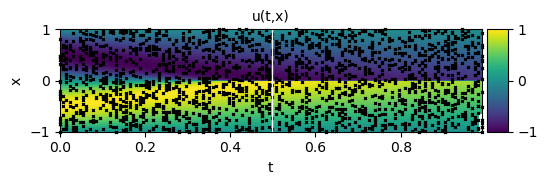

In [87]:
fig, ax = newfig(1.2, 1.2)
ax.axis('off')

# u(t,x)

gs0 = gridspec.GridSpec(1, 2)
gs0.update(top=1 - 0.06,
           bottom=1 - 1.0 / 3.0 + 0.06,
           left=0.15,
           right=0.85,
           wspace=0)
ax = plt.subplot(gs0[:, :])

h = ax.imshow(U_pred.T,
              interpolation='nearest',
              cmap='viridis',
              extent=[t.min(), t.max(), x.min(),
                      x.max()],
              origin='lower',
              aspect='auto')
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(h, cax=cax)

ax.plot(X_u_train[:, 1],
        X_u_train[:, 0],
        'kx',
        #label='Data (%d points)' % (u_train.shape[0]),
        markersize=2,
        clip_on=False)

t50 = t.size//2
line = np.linspace(x.min(), x.max(), 2)[:, None]
#ax.plot(t[25] * np.ones((2, 1)), line, 'w-', linewidth=1)
ax.plot(t[t50] * np.ones((2, 1)), line, 'w-', linewidth=1)
#ax.plot(t[75] * np.ones((2, 1)), line, 'w-', linewidth=1)

ax.set_xlabel('t')
ax.set_ylabel('x')
ax.legend(loc='upper center',
          bbox_to_anchor=(1.0, -0.125),
          ncol=5,
          frameon=False)
ax.set_title('u(t,x)', fontsize=10)

plt.show()

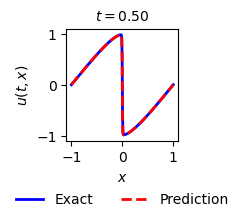

In [88]:
# u(t,x) slices

gs1 = gridspec.GridSpec(1, 1)
gs1.update(top=1 - 1.0 / 3.0 - 0.1,
           bottom=1.0 - 2.0 / 3.0,
           left=0.1,
           right=0.9,
           wspace=0.5)

ax = plt.subplot(gs1[0, 0])
ax.plot(x, Exact[t50, :], 'b-', linewidth=2, label='Exact')
ax.plot(x, U_pred[t50, :], 'r--', linewidth=2, label='Prediction')
ax.set_xlabel('$x$')
ax.set_ylabel('$u(t,x)$')
ax.axis('square')
ax.set_xlim([-1.1, 1.1])
ax.set_ylim([-1.1, 1.1])
ax.set_title('$t = 0.50$', fontsize=10)
ax.legend(loc='upper center',
          bbox_to_anchor=(0.5, -0.35),
          ncol=5,
          frameon=False)

plt.show()

<hr style="height:50px;border-width:0;background-color:green">

## Loss 3 - without MSE_u

viscosity = 0.01/np.pi

dataset = 256x128

In [89]:
nu = 0.01/np.pi  # viscosity
N_u = 2000  # nro of CPs
layers = [2, 20, 20, 20, 1]  # achitecture
data = np.load('../data/burgers256x128.npz')

## Main

In [90]:
t = data['t'].flatten()[:, None]
x = data['x'].flatten()[:, None]
Exact = np.real(data['usol']).T
X, T = np.meshgrid(x, t)
X_star = np.hstack((X.flatten()[:, None], T.flatten()[:, None]))
u_star = Exact.flatten()[:, None]

# Doman bounds
lb = X_star.min(0)
ub = X_star.max(0)

idx = np.random.choice(X_star.shape[0], N_u, replace=False)
X_u_train = X_star[idx, :]
u_train = u_star[idx, :]

In [91]:
x.size, t.size, Exact.size

(256, 128, 32768)

## Model

In [92]:
%%time
model = PhysicsInformedNN3(X_u_train, u_train, layers, lb, ub)

Device mapping:
/job:localhost/replica:0/task:0/device:XLA_CPU:0 -> device: XLA_CPU device
/job:localhost/replica:0/task:0/device:XLA_GPU:0 -> device: XLA_GPU device
/job:localhost/replica:0/task:0/device:GPU:0 -> device: 0, name: NVIDIA GeForce GTX 1050, pci bus id: 0000:01:00.0, compute capability: 6.1

ask:0/device:GPU:0
Reshape_816/shape: (Const): /job:localhost/replica:0/task:0/device:GPU:0
Reshape_817/shape: (Const): /job:localhost/replica:0/task:0/device:GPU:0
Reshape_818/shape: (Const): /job:localhost/replica:0/task:0/device:GPU:0
Reshape_819/shape: (Const): /job:localhost/replica:0/task:0/device:GPU:0
Reshape_820/shape: (Const): /job:localhost/replica:0/task:0/device:GPU:0
Reshape_821/shape: (Const): /job:localhost/replica:0/task:0/device:GPU:0
Reshape_822/shape: (Const): /job:localhost/replica:0/task:0/device:GPU:0
Reshape_823/shape: (Const): /job:localhost/replica:0/task:0/device:GPU:0
Reshape_824/shape: (Const): /job:localhost/replica:0/task:0/device:GPU:0
Reshape_825/shape

## Train

Computing-intensive part

In [93]:
%%time
model.train(0)

L-BFGS-B optimizer run.
Loss: 1.903041e-02, Lambda_1: 0.00000, Lambda_2: 0.00248
Loss: 1.255894e+01, Lambda_1: 0.00026, Lambda_2: 0.00248
Loss: 7.564658e-03, Lambda_1: 0.00001, Lambda_2: 0.00248
Loss: 7.346511e-03, Lambda_1: 0.00001, Lambda_2: 0.00248
Loss: 6.850594e-03, Lambda_1: 0.00002, Lambda_2: 0.00248
Loss: 5.696519e-03, Lambda_1: 0.00005, Lambda_2: 0.00248
Loss: 3.554112e-03, Lambda_1: 0.00012, Lambda_2: 0.00248
Loss: 7.110460e-04, Lambda_1: 0.00024, Lambda_2: 0.00248
Loss: 3.959068e-05, Lambda_1: 0.00033, Lambda_2: 0.00248
Loss: 2.848709e-05, Lambda_1: 0.00033, Lambda_2: 0.00248
Loss: 2.641170e-05, Lambda_1: 0.00033, Lambda_2: 0.00248
Loss: 2.405768e-05, Lambda_1: 0.00034, Lambda_2: 0.00248
Loss: 2.368933e-05, Lambda_1: 0.00034, Lambda_2: 0.00248
Loss: 2.252920e-05, Lambda_1: 0.00034, Lambda_2: 0.00248
Loss: 1.805881e-05, Lambda_1: 0.00036, Lambda_2: 0.00248
Loss: 1.040320e-05, Lambda_1: 0.00038, Lambda_2: 0.00248
Loss: 3.788929e-06, Lambda_1: 0.00023, Lambda_2: 0.00248
Loss: 2

## Predict

In [94]:
%%time
u_pred, f_pred = model.predict(X_star)
U_pred = griddata(X_star, u_pred.flatten(), (X, T), method='cubic')

CPU times: user 862 ms, sys: 116 ms, total: 978 ms
Wall time: 781 ms


### Show the identified PDE

In [95]:
lambda_1_value = model.sess.run(model.lambda_1)
lambda_2_value = model.sess.run(model.lambda_2)
lambda_2_value = np.exp(lambda_2_value)

In [96]:
print(r'Correct PDE   :  u_t + 1.0 u u_x - 0.0031831 u_{xx} = 0')
print(r'Identified PDE: ',
      r'u_t + %.5f u u_x - %.7f u_{xx} = 0' % (lambda_1_value, lambda_2_value))

Correct PDE   :  u_t + 1.0 u u_x - 0.0031831 u_{xx} = 0
Identified PDE:  u_t + 0.00028 u u_x - 0.0024788 u_{xx} = 0


## Error

- Uses the L2 norm (Euclidean distance)
- errou_u = distance error relative to distance

In [97]:
error_u = np.linalg.norm(u_star - u_pred, 2) / np.linalg.norm(u_star, 2)
error_lambda_1 = np.abs(lambda_1_value - 1.0) * 100
error_lambda_2 = np.abs(lambda_2_value - nu) / nu * 100
print('Error u: %e' % (error_u))
print('Error l1: %.5f%%' % (error_lambda_1))
print('Error l2: %.5f%%' % (error_lambda_2))

Error u: 1.092103e+00
Error l1: 99.97152%
Error l2: 22.12774%


## Plotting

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


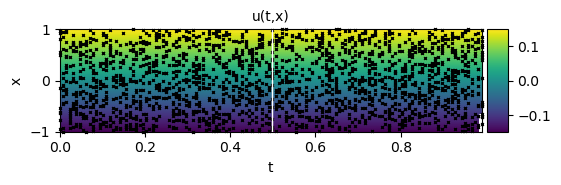

In [98]:
fig, ax = newfig(1.2, 1.2)
ax.axis('off')

# u(t,x)

gs0 = gridspec.GridSpec(1, 2)
gs0.update(top=1 - 0.06,
           bottom=1 - 1.0 / 3.0 + 0.06,
           left=0.15,
           right=0.85,
           wspace=0)
ax = plt.subplot(gs0[:, :])

h = ax.imshow(U_pred.T,
              interpolation='nearest',
              cmap='viridis',
              extent=[t.min(), t.max(), x.min(),
                      x.max()],
              origin='lower',
              aspect='auto')
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(h, cax=cax)

ax.plot(X_u_train[:, 1],
        X_u_train[:, 0],
        'kx',
        #label='Data (%d points)' % (u_train.shape[0]),
        markersize=2,
        clip_on=False)

t50 = t.size//2
line = np.linspace(x.min(), x.max(), 2)[:, None]
#ax.plot(t[25] * np.ones((2, 1)), line, 'w-', linewidth=1)
ax.plot(t[t50] * np.ones((2, 1)), line, 'w-', linewidth=1)
#ax.plot(t[75] * np.ones((2, 1)), line, 'w-', linewidth=1)

ax.set_xlabel('t')
ax.set_ylabel('x')
ax.legend(loc='upper center',
          bbox_to_anchor=(1.0, -0.125),
          ncol=5,
          frameon=False)
ax.set_title('u(t,x)', fontsize=10)

plt.show()

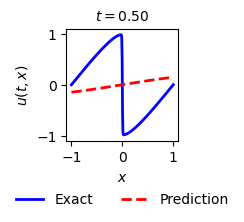

In [99]:
# u(t,x) slices

gs1 = gridspec.GridSpec(1, 1)
gs1.update(top=1 - 1.0 / 3.0 - 0.1,
           bottom=1.0 - 2.0 / 3.0,
           left=0.1,
           right=0.9,
           wspace=0.5)

ax = plt.subplot(gs1[0, 0])
ax.plot(x, Exact[t50, :], 'b-', linewidth=2, label='Exact')
ax.plot(x, U_pred[t50, :], 'r--', linewidth=2, label='Prediction')
ax.set_xlabel('$x$')
ax.set_ylabel('$u(t,x)$')
ax.axis('square')
ax.set_xlim([-1.1, 1.1])
ax.set_ylim([-1.1, 1.1])
ax.set_title('$t = 0.50$', fontsize=10)
ax.legend(loc='upper center',
          bbox_to_anchor=(0.5, -0.35),
          ncol=5,
          frameon=False)

plt.show()